# ARIMAX MULTI-STEP FORECASTING

Leakage-safe прогноз полного окна `[T+1, T+2, T+3, T+4, T+5]`, где шаг — следующая официальная quote observation, а не календарный день. Для каждого origin используется одна информационная точка T.

## 1. Переиспользуемые артефакты

EDA, stationarity analysis, полный ARIMA grid search и baseline training не повторяются. Notebook читает готовые temporal splits, выбранные ARIMA orders, causal feature dataset и сохранённые Naive/ARIMA forecasts.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'src').exists():
    raise RuntimeError(f'Не найден корень репозитория из {Path.cwd()}')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.arimax_multistep import plot_representative, run_arimax_multistep

required = [
    'data/features/fx_features_daily.parquet',
    'reports/temporal_split_horizons.csv',
    'reports/arima_rate_multistep_results.csv',
    'reports/arima_rate_test_forecasts.csv',
    'reports/naive_predictions.csv',
    'docs/base_feature_dictionary.md',
    'docs/cross_currency_methodology.md',
]
inventory = pd.DataFrame({'artifact': required, 'exists': [(ROOT / p).exists() for p in required]})
display(inventory)
if not inventory.exists.all():
    raise FileNotFoundError(inventory.loc[~inventory.exists, 'artifact'].tolist())

,artifact,exists
0,data/features/fx_features_daily.parquet,True
1,reports/temporal_split_horizons.csv,True
2,reports/arima_rate_multistep_results.csv,True
3,reports/arima_rate_test_forecasts.csv,True
4,reports/naive_predictions.csv,True
5,docs/base_feature_dictionary.md,True
6,docs/cross_currency_methodology.md,True


## 2. Model и frozen-exog scenario

Для каждого corridor используется `statsmodels.SARIMAX` с тем же `d` и предыдущим best order либо одним из ближайших простых orders. Максимум — четыре orders.

Для forecast origin T будущая exogenous matrix фиксируется:

```text
future_exog = [X_T, X_T, X_T, X_T, X_T]
```

Фактические `X_(T+1)...X_(T+5)` не передаются прогнозной функции. Между origin state обновляется только наблюдениями, которые уже стали доступны.

## 3. Полный воспроизводимый запуск

**TEST LOCKED.** Order и SET A/B выбираются только по validation. Primary metric — `Path_MAE_5`; затем `MAE_H5`, `Future_Best_MAE_5`, `RMSE_H5`. В пределах 1% выбирается более простой вариант.

In [2]:
run = run_arimax_multistep(ROOT, make_plots=False)
print('Status:', run['status'])
print('Dataset:', run['dataset_path'].relative_to(ROOT))
print('Validation candidates:', len(run['candidates']))
print('Test forecast origins:', len(run['forecasts']))

Status: PASS
Dataset: data\features\fx_features_daily.parquet
Validation candidates: 32
Test forecast origins: 1375


## 4. Exogenous feature sets

SET A содержит шесть собственных trailing-признаков. SET B добавляет короткие broad-RUB и corridor-specific returns. Все поля реально присутствуют в dataset. Проверки future-derived names, exact duplicates и `abs(train correlation) >= 0.95` выполняются на TRAIN.

In [3]:
for name, features in run['feature_sets'].items():
    print(name, len(features), features)
display(run['feature_audit'])

SET_A 6 ['ret_1', 'ret_3', 'ret_5', 'vol_20', 'dist_min_20', 'favourability_percentile_90']
SET_B 10 ['ret_1', 'ret_3', 'ret_5', 'vol_20', 'dist_min_20', 'favourability_percentile_90', 'broad_rub_return_1', 'broad_rub_return_3', 'corridor_specific_return_1', 'corridor_specific_return_3']


,feature_set,feature,available_at_t,used,train_missing_share,exact_duplicate_of,correlated_with,correlation,reason
0,SET_A,ret_1,True,True,0.000756,,,NaN,causal trailing/as-of feature
1,SET_A,ret_3,True,True,0.002269,,,NaN,causal trailing/as-of feature
2,SET_A,ret_5,True,True,0.003782,,,NaN,causal trailing/as-of feature
3,SET_A,vol_20,True,True,0.015129,,,NaN,causal trailing/as-of feature
4,SET_A,dist_min_20,True,True,0.014372,,,NaN,causal trailing/as-of feature
5,SET_A,favourability_percentile_90,True,True,0.068079,,,NaN,causal trailing/as-of feature
6,SET_B,ret_1,True,True,0.000756,,,NaN,causal trailing/as-of feature
7,SET_B,ret_3,True,True,0.002269,,,NaN,causal trailing/as-of feature
8,SET_B,ret_5,True,True,0.003782,,,NaN,causal trailing/as-of feature
9,SET_B,vol_20,True,True,0.015129,,,NaN,causal trailing/as-of feature


## 5. Existing split и previous ARIMA orders

Используются те же validation/test origins, что в предыдущем tournament: 274 validation и 275 test origins на коридор. Благодаря прежнему H10 eligibility все H5 paths полностью наблюдаемы.

In [4]:
display(run['splits'])
display(run['orders'].rename(columns={'p':'previous_p','d':'previous_d','q':'previous_q'}))

,corridor,train_start,train_end,validation_start,validation_end,test_start,test_end,n_train,n_validation,n_test,validation_origin_start,validation_origin_end,test_origin_start,test_origin_end,n_validation_origins,n_test_origins,n_right_censored_origins,forecast_horizons,primary_horizon,max_horizon
0,AMD_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
1,KGS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
2,KZT_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
3,TJS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
4,UZS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10


,corridor,previous_p,previous_d,previous_q
0,AMD_RUB,0,1,0
1,KGS_RUB,0,1,0
2,KZT_RUB,0,1,2
3,TJS_RUB,0,1,0
4,UZS_RUB,0,1,0


## 6. Validation candidates и selection

Всего проверяется 32 комбинации, а не новый большой ARIMA search. Каждая комбинация fit на TRAIN один раз, после чего state последовательно получает только уже наступившие validation observations без refit параметров.

In [5]:
candidate_view = run['candidates'][['corridor','p','d','q','feature_set','fit_status','converged','Path_MAE_5','MAE_H5','Future_Best_MAE_5','RMSE_H5']]
display(candidate_view)
display(run['selection_audit'])
display(run['selections'][['corridor','p','d','q','feature_set','n_features','Path_MAE_5','MAE_H5','Future_Best_MAE_5','RMSE_H5']])

,corridor,p,d,q,feature_set,fit_status,converged,Path_MAE_5,MAE_H5,Future_Best_MAE_5,RMSE_H5
0,AMD_RUB,0,1,0,SET_A,success,True,0.003138,0.004189,0.003764,0.006033
1,AMD_RUB,0,1,0,SET_B,success,True,0.003138,0.004189,0.003764,0.006033
2,AMD_RUB,1,1,0,SET_A,success,True,0.003171,0.004252,0.003729,0.006131
3,AMD_RUB,1,1,0,SET_B,success,True,0.003170,0.004250,0.003729,0.006129
4,AMD_RUB,0,1,1,SET_A,success,True,0.003138,0.004203,0.003752,0.006059
5,AMD_RUB,0,1,1,SET_B,success,True,0.003138,0.004203,0.003752,0.006059
6,KGS_RUB,0,1,0,SET_A,success,True,0.013804,0.018114,0.016632,0.026335
7,KGS_RUB,0,1,0,SET_B,success,True,0.013804,0.018114,0.016632,0.026335
8,KGS_RUB,1,1,0,SET_A,success,True,0.014045,0.018452,0.016492,0.026925
9,KGS_RUB,1,1,0,SET_B,success,True,0.014046,0.018458,0.016484,0.026947


,corridor,best_validation_Path_MAE_5,candidates_total,candidates_within_1pct,selected_order,selected_feature_set,selection_used_test
0,AMD_RUB,0.003138,6,4,"(0,1,0)",SET_A,False
1,KGS_RUB,0.013804,6,4,"(0,1,0)",SET_A,False
2,KZT_RUB,0.002656,8,2,"(0,1,0)",SET_A,False
3,TJS_RUB,0.118481,6,5,"(0,1,0)",SET_A,False
4,UZS_RUB,0.000098,6,4,"(0,1,0)",SET_A,False


,corridor,p,d,q,feature_set,n_features,Path_MAE_5,MAE_H5,Future_Best_MAE_5,RMSE_H5
0,AMD_RUB,0,1,0,SET_A,6,0.003138,0.004189,0.003764,0.006033
1,KGS_RUB,0,1,0,SET_A,6,0.013804,0.018114,0.016632,0.026335
2,KZT_RUB,0,1,0,SET_A,6,0.002656,0.003423,0.003408,0.004918
3,TJS_RUB,0,1,0,SET_A,6,0.118499,0.157081,0.136335,0.222627
4,UZS_RUB,0,1,0,SET_A,6,0.000098,0.000128,0.000116,0.000183


## 7. Test forecast vectors

Одна строка соответствует одному origin и содержит пять прогнозов, пять actual targets и 95% intervals. Actual future используется только после вызова forecast — для сохранения targets и evaluation.

In [6]:
required_vector_columns = [
    'corridor','date','rate_t',
    *[f'predicted_rate_h{h}' for h in range(1,6)],
    *[f'actual_rate_h{h}' for h in range(1,6)],
    'predicted_future_best_5','actual_future_best_5',
    'predicted_regret_5','actual_regret_5',
]
display(run['forecasts'][required_vector_columns].head())
print('Rows:', len(run['forecasts']))
print('Required schema:', set(required_vector_columns).issubset(run['forecasts'].columns))

,corridor,date,rate_t,predicted_rate_h1,predicted_rate_h2,predicted_rate_h3,predicted_rate_h4,predicted_rate_h5,actual_rate_h1,actual_rate_h2,actual_rate_h3,actual_rate_h4,actual_rate_h5,predicted_future_best_5,actual_future_best_5,predicted_regret_5,actual_regret_5
0,AMD_RUB,2025-07-12,0.202874,0.202874,0.202874,0.202874,0.202874,0.202874,0.204020,0.202953,0.203038,0.203545,0.203818,0.202874,0.202953,0.0,0.000000
1,AMD_RUB,2025-07-15,0.204020,0.204020,0.204020,0.204020,0.204020,0.204020,0.202953,0.203038,0.203545,0.203818,0.204068,0.204020,0.202953,0.0,0.005230
2,AMD_RUB,2025-07-16,0.202953,0.202953,0.202953,0.202953,0.202953,0.202953,0.203038,0.203545,0.203818,0.204068,0.203371,0.202953,0.203038,0.0,0.000000
3,AMD_RUB,2025-07-17,0.203038,0.203038,0.203038,0.203038,0.203038,0.203038,0.203545,0.203818,0.204068,0.203371,0.204344,0.203038,0.203371,0.0,0.000000
4,AMD_RUB,2025-07-18,0.203545,0.203545,0.203545,0.203545,0.203545,0.203545,0.203818,0.204068,0.203371,0.204344,0.205510,0.203545,0.203371,0.0,0.000855


Rows: 1375
Required schema: True


## 8. Test metrics и baseline ratios

Naive и ARIMA не переобучались: прочитаны сохранённые прогнозы и сопоставлены на точном intersection origins. Directional Accuracy использует прежнюю zero convention; изменения меньше `1e-12` считаются численным нулём.

In [7]:
display(run['results'])
display(run['baseline_results'])

,corridor,model,feature_set,order,MAE_H1,RMSE_H1,DirectionalAccuracy_H1,coverage_H1,mean_interval_width_H1,MAE_H2,...,Regret_MAE_5,n_forecasts,Path_MAE_5_ratio_vs_naive,MAE_H5_ratio_vs_naive,Future_Best_MAE_5_ratio_vs_naive,Regret_MAE_5_ratio_vs_naive,Path_MAE_5_ratio_vs_arima,MAE_H5_ratio_vs_arima,Future_Best_MAE_5_ratio_vs_arima,Regret_MAE_5_ratio_vs_arima
0,AMD_RUB,ARIMAX,SET_A,"(0, 1, 0)",0.001335,0.001765,0.000000,0.774545,0.004039,0.002044,...,0.010045,275,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000
1,KGS_RUB,ARIMAX,SET_A,"(0, 1, 0)",0.005722,0.007620,0.000000,0.789091,0.017753,0.008860,...,0.010534,275,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000
2,KZT_RUB,ARIMAX,SET_A,"(0, 1, 0)",0.001242,0.001653,0.000000,0.727273,0.003285,0.001882,...,0.011313,275,1.0,1.0,1.0,1.0,1.000408,1.006588,1.005507,1.026894
3,TJS_RUB,ARIMAX,SET_A,"(0, 1, 0)",0.054922,0.074090,0.003636,0.792727,0.163396,0.085604,...,0.010582,275,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000
4,UZS_RUB,ARIMAX,SET_A,"(0, 1, 0)",0.000048,0.000062,0.007273,0.814545,0.000153,0.000075,...,0.011373,275,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000


,corridor,model,MAE_H1,RMSE_H1,DirectionalAccuracy_H1,MAE_H2,RMSE_H2,DirectionalAccuracy_H2,MAE_H3,RMSE_H3,...,MAE_H4,RMSE_H4,DirectionalAccuracy_H4,MAE_H5,RMSE_H5,DirectionalAccuracy_H5,Path_MAE_5,Future_Best_MAE_5,Regret_MAE_5,n_forecasts
0,AMD_RUB,NAIVE,0.001335,0.001765,0.000000,0.002044,0.002687,0.000000,0.002689,0.003413,...,0.003132,0.003948,0.000000,0.003491,0.004413,0.000000,0.002538,0.002492,0.010045,275
1,AMD_RUB,ARIMA_RATE,0.001335,0.001765,0.000000,0.002044,0.002687,0.000000,0.002689,0.003413,...,0.003132,0.003948,0.000000,0.003491,0.004413,0.000000,0.002538,0.002492,0.010045,275
2,KGS_RUB,NAIVE,0.005722,0.007620,0.000000,0.008860,0.011634,0.000000,0.011664,0.014826,...,0.013609,0.017201,0.000000,0.015246,0.019270,0.000000,0.011020,0.011122,0.010534,275
3,KGS_RUB,ARIMA_RATE,0.005722,0.007620,0.000000,0.008860,0.011634,0.000000,0.011664,0.014826,...,0.013609,0.017201,0.000000,0.015246,0.019270,0.000000,0.011020,0.011122,0.010534,275
4,KZT_RUB,NAIVE,0.001242,0.001653,0.000000,0.001882,0.002428,0.000000,0.002288,0.002968,...,0.002643,0.003457,0.000000,0.002901,0.003878,0.000000,0.002191,0.002124,0.011313,275
5,KZT_RUB,ARIMA_RATE,0.001242,0.001659,0.541818,0.001909,0.002444,0.461818,0.002291,0.002979,...,0.002628,0.003468,0.538182,0.002882,0.003886,0.523636,0.002190,0.002113,0.011017,275
6,TJS_RUB,NAIVE,0.054922,0.074090,0.003636,0.085604,0.111818,0.000000,0.112715,0.141462,...,0.131013,0.163860,0.000000,0.145904,0.182237,0.000000,0.106032,0.105599,0.010582,275
7,TJS_RUB,ARIMA_RATE,0.054922,0.074090,0.003636,0.085604,0.111818,0.000000,0.112715,0.141462,...,0.131013,0.163860,0.000000,0.145904,0.182237,0.000000,0.106032,0.105599,0.010582,275
8,UZS_RUB,NAIVE,0.000048,0.000062,0.007273,0.000075,0.000096,0.000000,0.000096,0.000120,...,0.000107,0.000136,0.000000,0.000119,0.000149,0.000000,0.000089,0.000088,0.011373,275
9,UZS_RUB,ARIMA_RATE,0.000048,0.000062,0.007273,0.000075,0.000096,0.000000,0.000096,0.000120,...,0.000107,0.000136,0.000000,0.000119,0.000149,0.000000,0.000089,0.000088,0.011373,275


## 9. Prediction intervals

Statsmodels вернул конечные упорядоченные 95% intervals для каждого горизонта. Coverage — доля actual внутри интервала; width выражен в единицах соответствующего курса.

In [8]:
interval_columns = ['corridor', *[x for h in range(1,6) for x in (f'coverage_H{h}', f'mean_interval_width_H{h}')]]
display(run['results'][interval_columns])
display(run['fit_audit'])

,corridor,coverage_H1,mean_interval_width_H1,coverage_H2,mean_interval_width_H2,coverage_H3,mean_interval_width_H3,coverage_H4,mean_interval_width_H4,coverage_H5,mean_interval_width_H5
0,AMD_RUB,0.774545,0.004039,0.745455,0.005712,0.690909,0.006995,0.654545,0.008077,0.654545,0.009031
1,KGS_RUB,0.789091,0.017753,0.738182,0.025106,0.690909,0.030749,0.665455,0.035506,0.661818,0.039697
2,KZT_RUB,0.727273,0.003285,0.654545,0.004646,0.676364,0.005690,0.687273,0.006570,0.694545,0.007346
3,TJS_RUB,0.792727,0.163396,0.734545,0.231077,0.687273,0.283011,0.647273,0.326793,0.640000,0.365365
4,UZS_RUB,0.814545,0.000153,0.752727,0.000216,0.741818,0.000265,0.698182,0.000306,0.712727,0.000342


,corridor,feature_set,p,d,q,converged,warning_count,warning_messages,aic,bic,n_fit,frozen_exog_all_origins,n_origins
0,AMD_RUB,SET_A,0,1,0,True,0,,-16504.815661,-16467.562713,1515,True,275
1,KGS_RUB,SET_A,0,1,0,True,0,,-12024.455068,-11987.202120,1515,True,275
2,KZT_RUB,SET_A,0,1,0,True,0,,-17129.821794,-17092.568846,1515,True,275
3,TJS_RUB,SET_A,0,1,0,True,0,,-5307.861417,-5270.608469,1515,True,275
4,UZS_RUB,SET_A,0,1,0,True,0,,-26412.714540,-26375.461592,1515,True,275


## 10. Minimal representative visualization

Для каждого corridor строится ровно один representative plot: история до T и actual/ARIMAX/ARIMA/Naive paths на H1...H5. Графики не участвуют в selection.

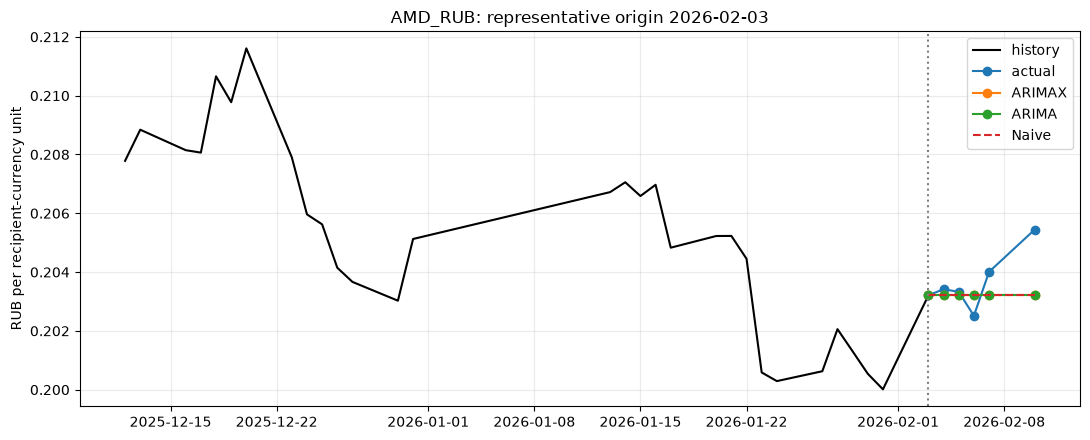

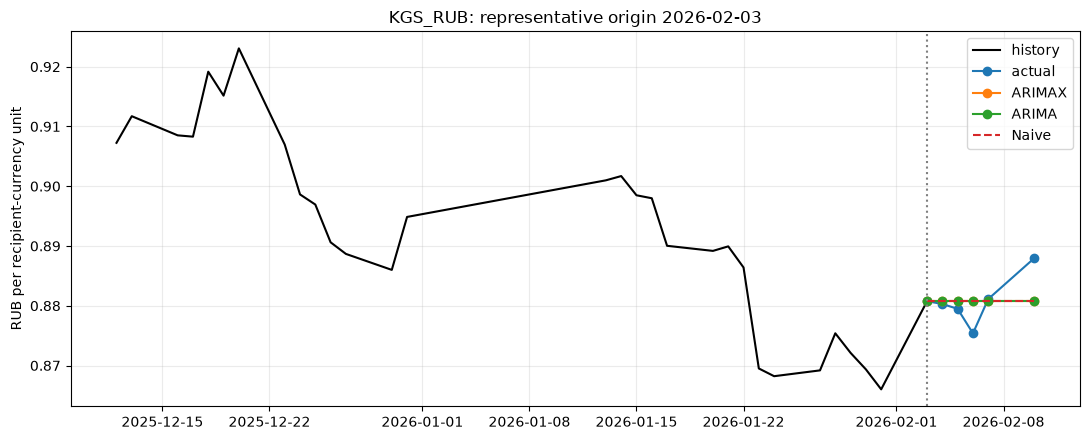

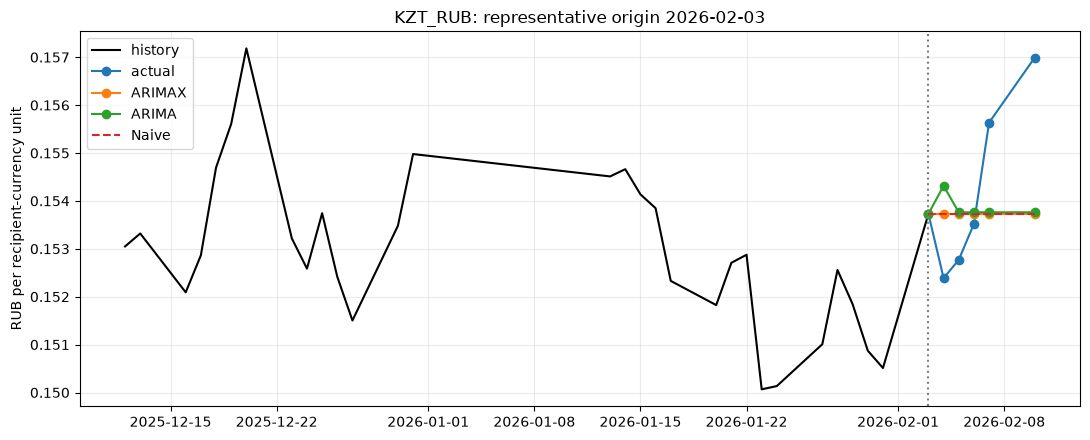

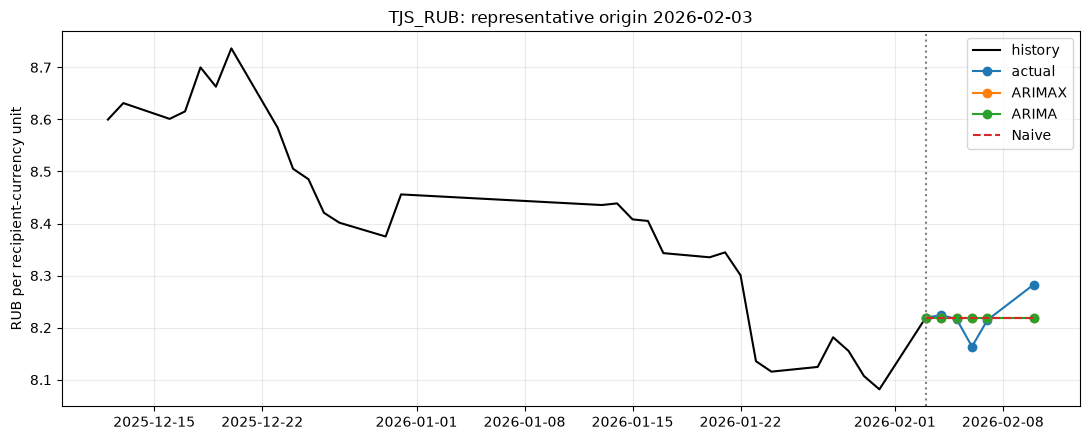

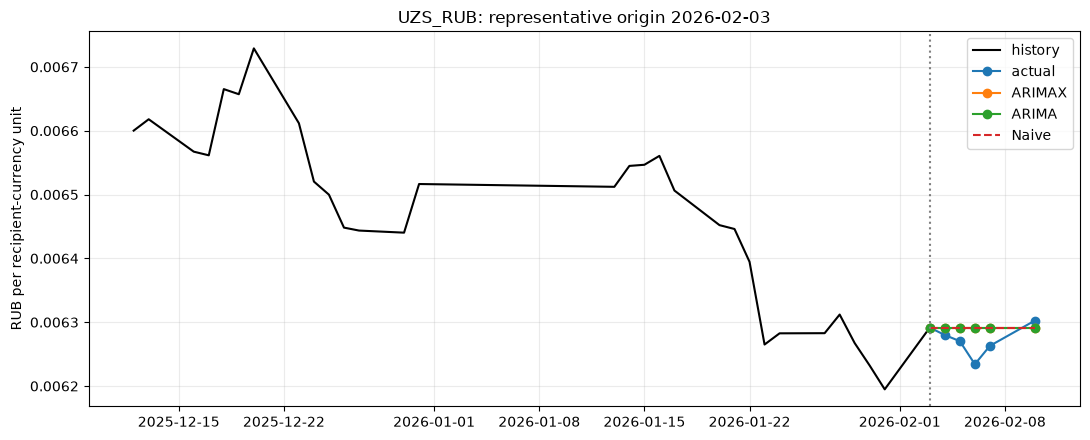

In [9]:
plot_representative(run['frame'], run['forecasts'], run['baselines'])

## 11. Leakage check

In [10]:
display(run['leakage'])
leakage_status = 'PASS' if run['leakage'].passed.all() else 'FAIL'
print('ARIMAX LEAKAGE CHECK:', leakage_status)

,check,passed
0,no future exog,True
1,frozen future exog = X_T,True
2,no actual future rates inside forecast,True
3,same temporal split,True
4,validation-only selection,True
5,test used once,True
6,same forecast origins as baselines,True
7,five forecasts from one origin,True
8,intervals finite and ordered,True


ARIMAX LEAKAGE CHECK: PASS


## 12. Итоговая интерпретация

Validation выбрала `SET_A + ARIMAX(0,1,0)` во всех пяти коридорах. При `d=1`, отсутствии AR/MA-компонент и frozen exog будущая разность exog равна нулю. Поэтому point forecast практически совпадает с Random Walk. Это полезный отрицательный результат: в выбранной постановке frozen-exog ARIMAX не извлекла дополнительную устойчивую точность; для KZT сохранённая ARIMA(0,1,2) остаётся лучше.

In [11]:
r = run['results']
eps = 1e-9
print('Best ARIMAX per corridor:')
print(r[['corridor','order','feature_set','Path_MAE_5','MAE_H5']].to_string(index=False))
print(f"ARIMAX beats ARIMA on Path_MAE: {(r.Path_MAE_5_ratio_vs_arima < 1-eps).sum()}/5")
print(f"ARIMAX beats Naive on Path_MAE: {(r.Path_MAE_5_ratio_vs_naive < 1-eps).sum()}/5")
print(f"ARIMAX improves Future_Best_MAE vs ARIMA: {(r.Future_Best_MAE_5_ratio_vs_arima < 1-eps).sum()}/5")
print(f"ARIMAX improves Regret_MAE vs ARIMA: {(r.Regret_MAE_5_ratio_vs_arima < 1-eps).sum()}/5")
print('ARIMAX LEAKAGE CHECK:', leakage_status)
print('Files:')
print('notebooks/03_arimax_multistep_forecasting.ipynb')
for key in ('forecasts','results','report'):
    print(run['outputs'][key].relative_to(ROOT).as_posix())

Best ARIMAX per corridor:
corridor     order feature_set  Path_MAE_5   MAE_H5
 AMD_RUB (0, 1, 0)       SET_A    0.002538 0.003491
 KGS_RUB (0, 1, 0)       SET_A    0.011020 0.015246
 KZT_RUB (0, 1, 0)       SET_A    0.002191 0.002901
 TJS_RUB (0, 1, 0)       SET_A    0.106032 0.145904
 UZS_RUB (0, 1, 0)       SET_A    0.000089 0.000119
ARIMAX beats ARIMA on Path_MAE: 0/5
ARIMAX beats Naive on Path_MAE: 0/5
ARIMAX improves Future_Best_MAE vs ARIMA: 0/5
ARIMAX improves Regret_MAE vs ARIMA: 0/5
ARIMAX LEAKAGE CHECK: PASS
Files:
notebooks/03_arimax_multistep_forecasting.ipynb
reports/arimax_h5_forecast_vectors.csv
reports/arimax_multistep_results.csv
reports/arimax_multistep_report.md
